# Импорты

In [ ]:
!pip install -q catboost
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
import optuna
from sklearn.metrics import f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline

In [ ]:
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
df = pd.read_excel("/content/data_1_2_well_cleanedv2.xlsx")
df.head(3)

# Предобработка

### Категориальные признаки

In [ ]:
irrelevant_columns = ['Столбец2', 'Столбец1','id', 'time_spent', 'comments', 'employment3', 'future_riskinformation']

df = df.drop(columns=irrelevant_columns)

In [ ]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
df[cat_cols]

In [ ]:
#ординальные
qualification_map = {'Нет':0, 'Первая':1, 'Вторая':2, 'Высшая':3}


income_level_map = {
    'Не хватает денег даже на еду':0,
    'Денег хватает на еду, но покупка одежды и оплата коммунальных услуг вызывает затруднения':1,
    'Денег хватает на еду и одежду, но покупка бытовой техники вызывает затруднения':2,
    'Денег хватает на одежду, еду и бытовую технику, но покупка автомобиля, квартиры или дачи вызывает затруднения':3,
    'Средств хватает чтобы купить все, что нужно':4
}

academic_degree_map = {'Нет':0, 'Кандидат наук':1, 'Доктор наук':2}

home_duty_map = {'Нет':0, 'Да':1}

change_hours_numb_map = {
    'Готов(а) ощутимо уменьшить':0,
    'Готов(а) слегка уменьшить':1,
    'Не готов(а)':2,
    'Готов(а) слегка увеличить':3,
    'Готов(а) ощутимо увеличить':4
}

expectation_prof_map = {
    'Определенно не оправдались':0,
    'Скорее не оправдались':1,
    'Скорее оправдались':2,
    'Определенно оправдались':3
}

schedule_map = {
    'Сменный график работы - ночь': 0,
    'Сменный график работы - день или вечер': 1,
    'Сменный график работы - сутки через трое': 2,
    'Пятидневная рабочая неделя': 3,
    'Шестидневная рабочая неделя': 4,
    'Другой': 5
}

burnout1_desc_map = {'Нет риска':0, 'Риск выгорания':1, 'Очень высокий риск выгорания':2}

org_type_map = { #по размеру
    'МИАЦ и ОИВ': 5,
    'Областная': 4,
    'Городская': 3,
    'СМП': 3,
    'Районная': 2,
    'Образование': 1,
    'Другие': 0,
    '-': 0
}

df['qualification'] = df['qualification'].map(qualification_map)
df['income_level'] = df['income_level'].map(income_level_map)
df['academic_degree'] = df['academic_degree'].map(academic_degree_map)
df['home_duty'] = df['home_duty'].map(home_duty_map)
df['change_hours_numb'] = df['change_hours_numb'].map(change_hours_numb_map)
df['expectation_prof'] = df['expectation_prof'].map(expectation_prof_map)
df['burnout1_desc'] = df['burnout1_desc'].map(burnout1_desc_map)
df['schedule'] = df['schedule'].map(schedule_map)
df['org_type'] = df['org_type'].map(org_type_map)

In [ ]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
df[cat_cols]

In [ ]:
num_cols = df.select_dtypes(exclude=["object", "category"]).columns
df[num_cols]

In [ ]:
# автоматически кодирую
for col in cat_cols:
    df[col] = pd.factorize(df[col])[0]

In [ ]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
df[cat_cols].head(3)

# Предсказания

In [ ]:
potential_targets = ['burnout1_integral', 'burnout1_desc', 'burnout1_dist', 'burnout1_exh', 'burnout1_emt', 'burnout1_cog']

In [ ]:
def train_and_validate_multiclass(df_given, target_col='target', drop_targets=[], classifier_type='catboost'):

    X = df_given.drop(columns=drop_targets)
    y = df_given[target_col]


    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), X.columns)
        ]
    )

    if classifier_type == 'logreg':
        clf = LogisticRegression(solver='lbfgs', multi_class='multinomial', class_weight='balanced', max_iter=1000)
    elif classifier_type == 'svc':
        clf = LinearSVC(class_weight='balanced', dual=False, max_iter=2000)
    elif classifier_type == 'rf':
        clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1)
    elif classifier_type == 'xgb':
        clf = XGBClassifier(eval_metric='mlogloss')
    elif classifier_type == 'catboost':
        clf = CatBoostClassifier(
            iterations=500,
            learning_rate=0.1,
            depth=6,
            silent=True,
            thread_count=-1
        )
    else:
        print("Что-то не так")

    pipeline = ImbPipeline([# для балансировки другой пайплайн
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', clf)
    ])

    print(f"5-fold CV для {classifier_type}")

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for tr, te in kf.split(X, y):
        model = clone(pipeline).fit(X.iloc[tr], y.iloc[tr])
        f1_per_class = f1_score(y.iloc[te], model.predict(X.iloc[te]), average=None)
        scores.append(f1_per_class)

    report = pd.DataFrame(scores, columns=[f'C{i}_F1' for i in range(len(scores[0]))])
    report.loc['MEAN'] = report.mean()
    report.loc['STD'] = report.iloc[:-1].std()
    print(report.round(3))


    scoring = ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy']
    cv_results = cross_validate(pipeline, X, y, cv=kf, scoring=scoring, n_jobs=-1)

    metrics_df = pd.DataFrame({
        'Фолд': [f'Fold {i+1}' for i in range(5)],
        'F1-score (macro)': cv_results['test_f1_macro'],
        'Precision (macro)': cv_results['test_precision_macro'],
        'Recall (macro)': cv_results['test_recall_macro'],
        'Accuracy': cv_results['test_accuracy']
    })

    stats = pd.DataFrame([
        {
            'Фолд': 'СРЕДНЕЕ (Mean)',
            'F1-score (macro)': metrics_df['F1-score (macro)'].mean(),
            'Precision (macro)': metrics_df['Precision (macro)'].mean(),
            'Recall (macro)': metrics_df['Recall (macro)'].mean(),
            'Accuracy': metrics_df['Accuracy'].mean()
        },
        {
            'Фолд': 'ОТКЛОНЕНИЕ (Std)',
            'F1-score (macro)': metrics_df['F1-score (macro)'].std(),
            'Precision (macro)': metrics_df['Precision (macro)'].std(),
            'Recall (macro)': metrics_df['Recall (macro)'].std(),
            'Accuracy': metrics_df['Accuracy'].std()
        }
    ])

    final_report = pd.concat([metrics_df, stats], ignore_index=True)
    print("\nРезультаты:")
    print(final_report.round(4))

    pipeline.fit(X, y)


    return pipeline, final_report

In [ ]:
def print_feature_importance_with_viz(pipeline, top_n=10):
    preprocessor = pipeline.named_steps['preprocessor']
    all_features = preprocessor.get_feature_names_out()
    clf = pipeline.named_steps['clf']

    if hasattr(clf, 'coef_'):
        importances = np.abs(clf.coef_)
        if importances.ndim > 1:
            importances = importances.mean(axis=0)
    elif hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
    else:
        print("Модель не поддерживает извлечение важностей.")
        return

    importances_pct = (importances / importances.sum()) * 100
    feat_imp = pd.Series(importances_pct, index=all_features).sort_values(ascending=False)


    plot_data = feat_imp.head(top_n).copy()
    others_val = feat_imp.iloc[top_n:].sum()
    others_count = len(feat_imp) - top_n

    if others_count > 0:
        plot_data[f'Остальные ({others_count} факторов)'] = others_val

    print(f"\nTOP-{top_n} IMPORTANT FEATURES (Relative to 100%)")
    print(plot_data.to_string())

    plt.figure(figsize=(10, 8))
    sns.set_style("whitegrid")


    viz_data = plot_data.sort_values(ascending=True)
    colors = ['#4C72B0' if 'Остальные' not in label else '#C44E52' for label in viz_data.index]

    bars = plt.barh(viz_data.index, viz_data.values, color=colors)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}%', va='center', fontsize=10, fontweight='bold')

    plt.title(f'Вклад ТОП-{top_n} факторов в модель выгорания', fontsize=14, pad=20)
    plt.xlabel('Доля влияния в % (Сумма всех = 100%)', fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
def print_feature_importance(pipeline, top_n=10):
    preprocessor = pipeline.named_steps['preprocessor']

    all_features = []
    for transformer in preprocessor.transformers_:
        names, _, cols = transformer
        if names == 'remainder' and cols == 'drop': continue
        all_features.extend(cols)

    clf = pipeline.named_steps['clf']

    if hasattr(clf, 'coef_'):
          importances = np.abs(clf.coef_).mean(axis=0)
    elif hasattr(clf, 'feature_importances_'):
          importances = clf.feature_importances_

    importances = (importances / importances.sum()) * 100

    feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

    print(f"\nTOP-{top_n} IMPORTANT FEATURES")
    print(feat_imp.head(top_n).to_string())

    feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=True).tail(top_n)

    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color='skyblue', edgecolor='black')

    plt.title(f'Top {top_n} наиболее значимых факторов', fontsize=14)
    plt.xlabel('Вес фактора (важность)', fontsize=12)
    plt.ylabel('Признаки', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


5-fold CV для logreg
      C0_F1  C1_F1  C2_F1
0      1.00   1.00   1.00
1      1.00   1.00   1.00
2      1.00   0.99   0.99
3      1.00   1.00   1.00
4      1.00   1.00   1.00
MEAN   1.00   1.00   1.00
STD    0.00   0.00   0.00

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              1.00               1.00            1.00      1.00
1            Fold 2              1.00               1.00            1.00      1.00
2            Fold 3              1.00               1.00            1.00      1.00
3            Fold 4              1.00               1.00            1.00      1.00
4            Fold 5              1.00               1.00            1.00      1.00
5    СРЕДНЕЕ (Mean)              1.00               1.00            1.00      1.00
6  ОТКЛОНЕНИЕ (Std)              0.00               0.00            0.00      0.00

TOP-10 IMPORTANT FEATURES
edu_4    8.96
edu_3    8.71
edu_1    8.54
edu_6    8.53
edu_2    8.

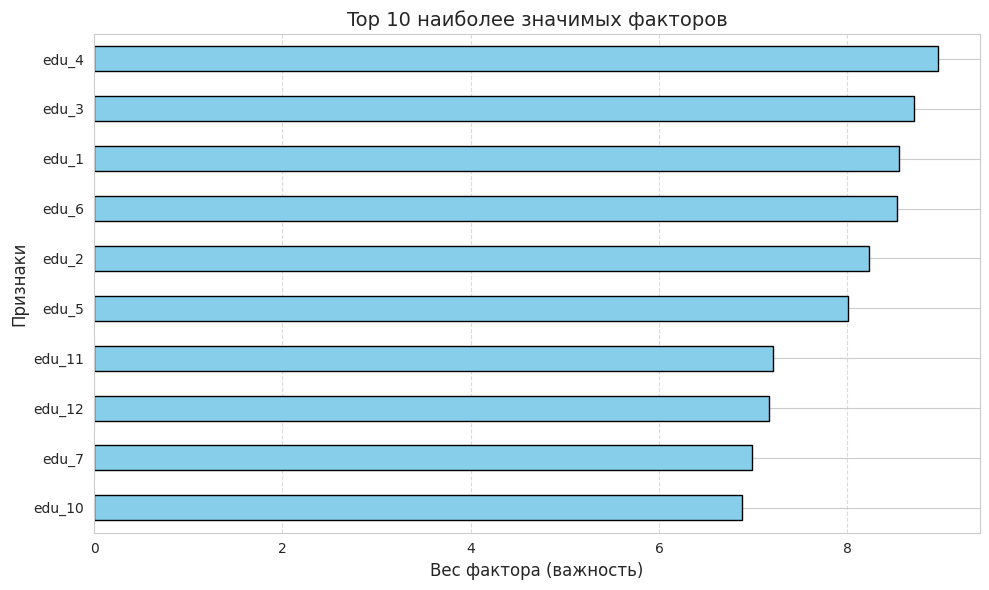

In [ ]:
model =  train_and_validate_multiclass(df, target_col='burnout1_desc',
                                       drop_targets=['burnout1_integral','burnout1_desc','burnout1_dist','burnout1_exh','burnout1_emt','burnout1_cog'],
                                       classifier_type='logreg')
print_feature_importance(model[0], 10)

In [ ]:
df.drop(columns=['burnout1_integral','burnout1_desc','burnout1_dist','burnout1_exh','burnout1_emt','burnout1_cog']).columns

Index(['Регион', 'Минуты', 'Часы', 'employment', 'employment2', 'satisfaction', 'state_at_the_moment', 'edu_1', 'edu_2', 'edu_3', 'edu_4', 'edu_5', 'edu_6', 'edu_7', 'edu_8', 'edu_9', 'edu_10', 'edu_11', 'edu_12', 'shift_org_1', 'shift_reg_1', 'shift_spec_1', 'shift_prof_1', 'gender', 'age', 'org_type', 'specialisation', 'qualification', 'exper', 'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours', 'condition_org', 'income_level', 'academic_degree', 'home_duty', 'change_hours_numb', 'expectation_prof', 'schedule', 'Длина коммента', 'future_interest', 'future_prestige', 'future_equipment', 'future_comfort', 'future_justice', 'future_social_help', 'future_organisation', 'future_selfgrowth', 'future_colleagues', 'future_leader', 'future_corpprocess', 'future_information', 'future_schedule', 'future_riskinformation2', 'future_patients', 'future_region', 'future_region_healthcare', 'age_number'], dtype='object')

### Убираем эмоциональные признаки edu и признаки заполнения опроса

In [ ]:
relevant = ['Регион', 'employment', 'employment2', 'satisfaction', 'state_at_the_moment',
            'shift_org_1', 'shift_reg_1', 'shift_spec_1', 'shift_prof_1', 'gender', 'age', 'org_type', 'specialisation', 'qualification', 'exper',
            'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours', 'condition_org', 'income_level', 'academic_degree', 'home_duty', 'change_hours_numb',
            'expectation_prof', 'schedule', 'future_interest', 'future_prestige', 'future_equipment', 'future_comfort', 'future_justice',
            'future_social_help', 'future_organisation', 'future_selfgrowth', 'future_colleagues', 'future_leader', 'future_corpprocess', 'future_information',
            'future_schedule', 'future_patients', 'future_region', 'future_region_healthcare', 'age_number']
relevant += ['burnout1_desc']

In [ ]:
model =  train_and_validate_multiclass(df[relevant], target_col='burnout1_desc',
                                       drop_targets=['burnout1_desc'],
                                       classifier_type='logreg')
print_feature_importance(model[0], 10)

5-fold CV для logreg
      C0_F1  C1_F1  C2_F1
0      0.82   0.31   0.53
1      0.83   0.30   0.52
2      0.84   0.33   0.55
3      0.83   0.28   0.53
4      0.83   0.30   0.52
MEAN   0.83   0.30   0.53
STD    0.01   0.02   0.01

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              0.55               0.54            0.61      0.69
1            Fold 2              0.55               0.54            0.59      0.70
2            Fold 3              0.57               0.55            0.62      0.71
3            Fold 4              0.54               0.53            0.59      0.69
4            Fold 5              0.55               0.54            0.60      0.70
5    СРЕДНЕЕ (Mean)              0.55               0.54            0.60      0.70
6  ОТКЛОНЕНИЕ (Std)              0.01               0.01            0.01      0.01

TOP-10 IMPORTANT FEATURES
employment2           9.22
employment            6.91
future_social

In [ ]:
models = ['logreg', 'svc', 'rf', 'xgb', 'catboost']

In [ ]:
for _ in models:
  model =  train_and_validate_multiclass(df[relevant], target_col='burnout1_desc',
                                        drop_targets=['burnout1_desc'],
                                        classifier_type=_)
  print('\n\n')

5-fold CV для logreg
      C0_F1  C1_F1  C2_F1
0      0.82   0.31   0.53
1      0.83   0.30   0.52
2      0.84   0.33   0.55
3      0.83   0.28   0.53
4      0.83   0.30   0.52
MEAN   0.83   0.30   0.53
STD    0.01   0.02   0.01

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              0.55               0.54            0.61      0.69
1            Fold 2              0.55               0.54            0.59      0.70
2            Fold 3              0.57               0.55            0.62      0.71
3            Fold 4              0.54               0.53            0.59      0.69
4            Fold 5              0.55               0.54            0.60      0.70
5    СРЕДНЕЕ (Mean)              0.55               0.54            0.60      0.70
6  ОТКЛОНЕНИЕ (Std)              0.01               0.01            0.01      0.01



5-fold CV для svc
      C0_F1  C1_F1  C2_F1
0      0.86   0.24   0.51
1      0.86   0.24   

###Демографические признаки

In [ ]:
relevant = ['Регион', 'employment', 'employment2',
            'gender', 'age', 'org_type', 'specialisation', 'qualification', 'exper', 'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours',
            'condition_org', 'income_level', 'academic_degree', 'home_duty', 'schedule',  'age_number']
relevant += ['burnout1_desc']

In [ ]:
for _ in models:
  model =  train_and_validate_multiclass(df[relevant], target_col='burnout1_desc',
                                        drop_targets=['burnout1_desc'],
                                        classifier_type=_)
  print('\n\n')


5-fold CV для logreg
      C0_F1  C1_F1  C2_F1
0      0.77   0.24   0.44
1      0.78   0.26   0.41
2      0.79   0.19   0.41
3      0.80   0.21   0.43
4      0.80   0.26   0.45
MEAN   0.79   0.23   0.43
STD    0.01   0.03   0.02

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              0.48               0.48            0.55      0.63
1            Fold 2              0.48               0.47            0.54      0.63
2            Fold 3              0.46               0.46            0.51      0.63
3            Fold 4              0.48               0.47            0.53      0.64
4            Fold 5              0.50               0.49            0.55      0.65
5    СРЕДНЕЕ (Mean)              0.48               0.47            0.53      0.64
6  ОТКЛОНЕНИЕ (Std)              0.01               0.01            0.02      0.01



5-fold CV для svc
      C0_F1  C1_F1  C2_F1
0      0.81   0.16   0.44
1      0.81   0.18   

In [ ]:
relevant = ['Регион', 'employment', 'employment2',
            'gender', 'age', 'org_type', 'specialisation', 'qualification', 'exper', 'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours',
            'condition_org', 'income_level', 'academic_degree', 'home_duty', 'schedule',  'age_number']
relevant += ['burnout1_desc']

5-fold CV для logreg
      C0_F1  C1_F1  C2_F1
0      0.66   0.19   0.29
1      0.68   0.18   0.28
2      0.68   0.18   0.28
3      0.66   0.18   0.27
4      0.68   0.19   0.32
MEAN   0.67   0.18   0.29
STD    0.01   0.01   0.02

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              0.38               0.40            0.44      0.51
1            Fold 2              0.38               0.39            0.43      0.52
2            Fold 3              0.38               0.40            0.43      0.52
3            Fold 4              0.37               0.39            0.42      0.49
4            Fold 5              0.40               0.41            0.46      0.53
5    СРЕДНЕЕ (Mean)              0.38               0.40            0.44      0.51
6  ОТКЛОНЕНИЕ (Std)              0.01               0.01            0.02      0.01

TOP-20 IMPORTANT FEATURES
income_level      15.38
employment2       15.13
age_number        1

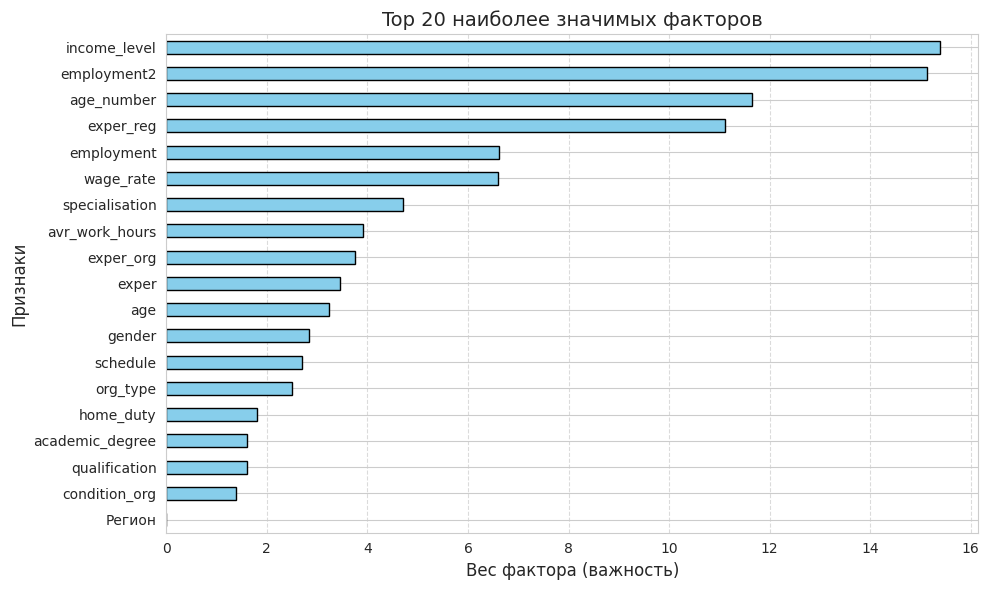

In [ ]:
model =  train_and_validate_multiclass(df[relevant], target_col='burnout1_desc',
                                        drop_targets=['burnout1_desc'],
                                        classifier_type='logreg')

print_feature_importance(model[0], 20)

## Сокращение фичей с 3х до 2х часть 2

In [ ]:
df['burnout1_desc_cut'] = df['burnout1_desc'].apply(lambda x: 0 if x < 2 else 1)
df.burnout1_desc_cut.value_counts()

,count
burnout1_desc_cut,
0,9727
1,1286


### Демографические признаки

In [ ]:
relevant = ['Регион', 'employment', 'employment2', 'shift_org_1', 'shift_reg_1', 'shift_spec_1', 'shift_prof_1',
            'gender', 'age', 'org_type', 'specialisation', 'qualification', 'exper', 'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours',
            'condition_org', 'income_level', 'academic_degree', 'home_duty', 'schedule', 'age_number']
relevant += ['burnout1_desc_cut']

In [ ]:
for _ in models:
  model =  train_and_validate_multiclass(df[relevant], target_col='burnout1_desc_cut',
                                        drop_targets=['burnout1_desc_cut'],
                                        classifier_type=_)
  print('\n\n')


5-fold CV для logreg
      C0_F1  C1_F1
0      0.76   0.30
1      0.77   0.29
2      0.75   0.28
3      0.75   0.28
4      0.76   0.30
MEAN   0.76   0.29
STD    0.01   0.01

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              0.53               0.56            0.64      0.64
1            Fold 2              0.53               0.56            0.63      0.66
2            Fold 3              0.51               0.55            0.63      0.63
3            Fold 4              0.51               0.55            0.62      0.63
4            Fold 5              0.53               0.57            0.65      0.64
5    СРЕДНЕЕ (Mean)              0.52               0.56            0.64      0.64
6  ОТКЛОНЕНИЕ (Std)              0.01               0.01            0.01      0.01



5-fold CV для svc
      C0_F1  C1_F1
0      0.76   0.30
1      0.77   0.29
2      0.75   0.28
3      0.75   0.28
4      0.76   0.30
MEAN   0.76   0

In [ ]:
relevant = ['Регион', 'employment', 'employment2',
            'gender', 'age', 'org_type', 'specialisation', 'qualification', 'exper', 'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours',
            'condition_org', 'income_level', 'academic_degree', 'home_duty', 'schedule',  'age_number']
relevant += ['burnout1_desc_cut']

In [ ]:
model =  train_and_validate_multiclass(df[relevant], target_col='burnout1_desc_cut',
                                        drop_targets=['burnout1_desc_cut'],
                                        classifier_type='logreg')

print_feature_importance(model[0], 10)

5-fold CV для logreg
      C0_F1  C1_F1
0      0.76   0.30
1      0.77   0.29
2      0.75   0.28
3      0.75   0.28
4      0.76   0.30
MEAN   0.76   0.29
STD    0.01   0.01

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              0.53               0.56            0.64      0.64
1            Fold 2              0.53               0.56            0.63      0.66
2            Fold 3              0.51               0.55            0.63      0.63
3            Fold 4              0.51               0.55            0.62      0.63
4            Fold 5              0.53               0.57            0.65      0.64
5    СРЕДНЕЕ (Mean)              0.52               0.56            0.64      0.64
6  ОТКЛОНЕНИЕ (Std)              0.01               0.01            0.01      0.01

TOP-10 IMPORTANT FEATURES
employment2      16.82
income_level     15.25
age_number       13.54
exper_reg        12.72
wage_rate         7.15
speciali

### Обрезанный edu

In [ ]:
relevant = ['Регион', 'employment', 'employment2', 'satisfaction', 'state_at_the_moment',
            'shift_org_1', 'shift_reg_1', 'shift_spec_1', 'shift_prof_1', 'gender', 'age', 'org_type', 'specialisation', 'qualification', 'exper',
            'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours', 'condition_org', 'income_level', 'academic_degree', 'home_duty', 'change_hours_numb',
            'expectation_prof', 'schedule', 'future_interest', 'future_prestige', 'future_equipment', 'future_comfort', 'future_justice',
            'future_social_help', 'future_organisation', 'future_selfgrowth', 'future_colleagues', 'future_leader', 'future_corpprocess', 'future_information',
            'future_schedule', 'future_patients', 'future_region', 'future_region_healthcare', 'age_number']
relevant += ['burnout1_desc_cut']

In [ ]:
for _ in models:
  model =  попрощ(df[relevant], target_col='burnout1_desc_cut',
                                        drop_targets=['burnout1_desc_cut'],
                                        classifier_type=_)
  print('\n\n')

5-fold CV для logreg
      C0_F1  C1_F1
0      0.89   0.51
1      0.88   0.49
2      0.89   0.50
3      0.89   0.51
4      0.90   0.51
MEAN   0.89   0.50
STD    0.01   0.01

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              0.70               0.67            0.81      0.82
1            Fold 2              0.68               0.66            0.80      0.81
2            Fold 3              0.69               0.67            0.81      0.81
3            Fold 4              0.70               0.67            0.81      0.82
4            Fold 5              0.70               0.67            0.80      0.83
5    СРЕДНЕЕ (Mean)              0.69               0.67            0.80      0.82
6  ОТКЛОНЕНИЕ (Std)              0.01               0.00            0.01      0.01



5-fold CV для svc
      C0_F1  C1_F1
0      0.89   0.50
1      0.88   0.49
2      0.89   0.50
3      0.89   0.50
4      0.89   0.51
MEAN   0.89   0

In [ ]:
relevant = ['Регион', 'employment', 'employment2', 'satisfaction', 'state_at_the_moment',
            'shift_org_1', 'shift_reg_1', 'shift_spec_1', 'shift_prof_1', 'gender', 'age', 'org_type', 'specialisation', 'qualification', 'exper',
            'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours', 'condition_org', 'income_level', 'academic_degree', 'home_duty', 'change_hours_numb',
            'expectation_prof', 'schedule', 'future_interest', 'future_prestige', 'future_equipment', 'future_comfort', 'future_justice',
            'future_social_help', 'future_organisation', 'future_selfgrowth', 'future_colleagues', 'future_leader', 'future_corpprocess', 'future_information',
            'future_schedule', 'future_patients', 'future_region', 'future_region_healthcare', 'age_number']
relevant += ['burnout1_desc_cut']

In [ ]:
model =  train_and_validate_multiclass(df[relevant], target_col='burnout1_desc_cut',
                                        drop_targets=['burnout1_desc_cut'],
                                        classifier_type='catboost')

print_feature_importance(model[0], 10)

5-fold CV для catboost
      C0_F1  C1_F1
0      0.95   0.51
1      0.94   0.49
2      0.94   0.50
3      0.95   0.49
4      0.95   0.50
MEAN   0.95   0.50
STD    0.00   0.01

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              0.73               0.79            0.69      0.91
1            Fold 2              0.72               0.77            0.69      0.90
2            Fold 3              0.72               0.76            0.70      0.90
3            Fold 4              0.72               0.78            0.69      0.90
4            Fold 5              0.72               0.80            0.68      0.91
5    СРЕДНЕЕ (Mean)              0.72               0.78            0.69      0.90
6  ОТКЛОНЕНИЕ (Std)              0.00               0.02            0.01      0.00

TOP-10 IMPORTANT FEATURES
shift_org_1           9.97
state_at_the_moment   7.63
shift_reg_1           7.49
shift_prof_1          7.24
wage_rate    

### Только edu-признаки

In [ ]:
relevant = ['edu_1', 'edu_2', 'edu_3', 'edu_4', 'edu_5', 'edu_6', 'edu_7', 'edu_8', 'edu_9', 'edu_10', 'edu_11', 'edu_12']
relevant += ['burnout1_desc']

In [ ]:
for _ in models:
  model =  train_and_validate_multiclass(df[relevant], target_col='burnout1_desc',
                                        drop_targets=['burnout1_desc'],
                                        classifier_type=_)
  print('\n\n')


5-fold CV для logreg
      C0_F1  C1_F1  C2_F1
0      1.00   1.00   1.00
1      1.00   1.00   1.00
2      1.00   1.00   1.00
3      1.00   1.00   1.00
4      1.00   1.00   1.00
MEAN   1.00   1.00   1.00
STD    0.00   0.00   0.00

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              1.00               1.00            1.00      1.00
1            Fold 2              1.00               1.00            1.00      1.00
2            Fold 3              1.00               1.00            1.00      1.00
3            Fold 4              1.00               1.00            1.00      1.00
4            Fold 5              1.00               1.00            1.00      1.00
5    СРЕДНЕЕ (Mean)              1.00               1.00            1.00      1.00
6  ОТКЛОНЕНИЕ (Std)              0.00               0.00            0.00      0.00



5-fold CV для svc
      C0_F1  C1_F1  C2_F1
0      1.00   1.00   1.00
1      1.00   1.00   

## Ключевые признаки

In [ ]:
relevant = ['burnout1_desc','burnout1_dist','burnout1_exh','burnout1_emt','burnout1_cog']
relevant += ['burnout1_desc_cut']

In [ ]:
model =  train_and_validate_multiclass(df[relevant], target_col='burnout1_desc',
                                       drop_targets=['burnout1_desc','burnout1_desc_cut'],
                                       classifier_type='logreg')
print_feature_importance(model[0], 10)

5-fold CV для logreg
      C0_F1  C1_F1  C2_F1
0      1.00   1.00   1.00
1      1.00   1.00   1.00
2      1.00   1.00   1.00
3      1.00   1.00   1.00
4      1.00   1.00   1.00
MEAN   1.00   1.00   1.00
STD    0.00   0.00   0.00

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              1.00               1.00            1.00      1.00
1            Fold 2              1.00               1.00            1.00      1.00
2            Fold 3              1.00               1.00            1.00      1.00
3            Fold 4              1.00               1.00            1.00      1.00
4            Fold 5              1.00               1.00            1.00      1.00
5    СРЕДНЕЕ (Mean)              1.00               1.00            1.00      1.00
6  ОТКЛОНЕНИЕ (Std)              0.00               0.00            0.00      0.00

TOP-10 IMPORTANT FEATURES
burnout1_exh    28.02
burnout1_dist   27.34
burnout1_emt    23.45
b

In [ ]:
model =  train_and_validate_multiclass(df, target_col='burnout1_desc',
                                       drop_targets=['burnout1_integral','burnout1_desc','burnout1_dist','burnout1_exh','burnout1_emt','burnout1_cog'],
                                       classifier_type='logreg')
print_feature_importance(model[0], 10)

5-fold CV для logreg
      C0_F1  C1_F1  C2_F1
0      1.00   1.00   1.00
1      1.00   1.00   1.00
2      1.00   0.99   0.99
3      1.00   1.00   1.00
4      1.00   1.00   1.00
MEAN   1.00   1.00   1.00
STD    0.00   0.00   0.00

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              1.00               1.00            1.00      1.00
1            Fold 2              1.00               1.00            1.00      1.00
2            Fold 3              1.00               1.00            1.00      1.00
3            Fold 4              1.00               1.00            1.00      1.00
4            Fold 5              1.00               1.00            1.00      1.00
5    СРЕДНЕЕ (Mean)              1.00               1.00            1.00      1.00
6  ОТКЛОНЕНИЕ (Std)              0.00               0.00            0.00      0.00

TOP-10 IMPORTANT FEATURES
edu_4    8.96
edu_3    8.71
edu_1    8.54
edu_6    8.53
edu_2    8.

In [ ]:
df.columns

Index(['Регион', 'Минуты', 'Часы', 'employment', 'employment2', 'satisfaction', 'state_at_the_moment', 'edu_1', 'edu_2', 'edu_3', 'edu_4', 'edu_5', 'edu_6', 'edu_7', 'edu_8', 'edu_9', 'edu_10', 'edu_11', 'edu_12', 'shift_org_1', 'shift_reg_1', 'shift_spec_1', 'shift_prof_1', 'gender', 'age', 'org_type', 'specialisation', 'qualification', 'exper', 'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours', 'condition_org', 'income_level', 'academic_degree', 'home_duty', 'change_hours_numb', 'expectation_prof', 'schedule', 'Длина коммента', 'future_interest', 'future_prestige', 'future_equipment', 'future_comfort', 'future_justice', 'future_social_help', 'future_organisation', 'future_selfgrowth', 'future_colleagues', 'future_leader', 'future_corpprocess', 'future_information', 'future_schedule', 'future_riskinformation2', 'future_patients', 'future_region', 'future_region_healthcare', 'burnout1_integral', 'burnout1_desc', 'burnout1_exh', 'burnout1_dist', 'burnout1_cog', 'burnout1_emt',
   

5-fold CV для logreg
      C0_F1  C1_F1  C2_F1
0      1.00   1.00   1.00
1      1.00   1.00   1.00
2      1.00   1.00   1.00
3      1.00   1.00   1.00
4      1.00   1.00   1.00
MEAN   1.00   1.00   1.00
STD    0.00   0.00   0.00

Результаты:
               Фолд  F1-score (macro)  Precision (macro)  Recall (macro)  Accuracy
0            Fold 1              1.00               1.00            1.00      1.00
1            Fold 2              1.00               1.00            1.00      1.00
2            Fold 3              1.00               1.00            1.00      1.00
3            Fold 4              1.00               1.00            1.00      1.00
4            Fold 5              1.00               1.00            1.00      1.00
5    СРЕДНЕЕ (Mean)              1.00               1.00            1.00      1.00
6  ОТКЛОНЕНИЕ (Std)              0.00               0.00            0.00      0.00

TOP-12 IMPORTANT FEATURES
edu_4    9.77
edu_1    9.27
edu_3    9.26
edu_6    9.24
edu_2    9.

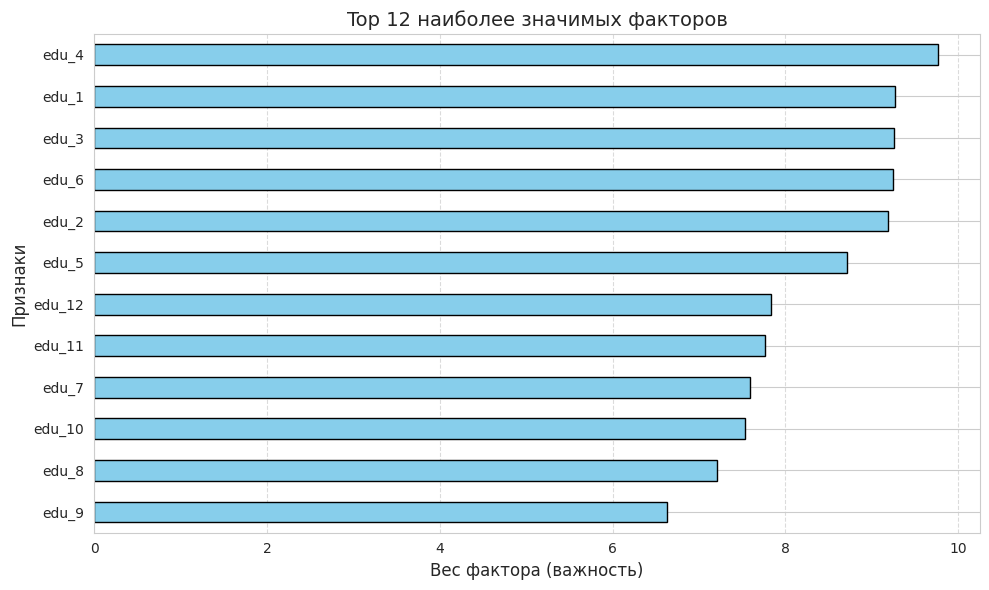

In [ ]:
relevant = ['edu_1', 'edu_2', 'edu_3', 'edu_4', 'edu_5', 'edu_6', 'edu_7', 'edu_8', 'edu_9', 'edu_10', 'edu_11', 'edu_12']
relevant += ['burnout1_desc']

pipeline, _  =  train_and_validate_multiclass(df[relevant], target_col='burnout1_desc',
                                       drop_targets=['burnout1_desc'],
                                       classifier_type='logreg')

print_feature_importance(pipeline, 12)